# Chain of Thoughts (CoT)

## Definition
**Chain of Thoughts** is a prompting technique that instructs language models to break down complex problems into intermediate reasoning steps before arriving at a final answer. Instead of providing a direct answer, the model shows its step-by-step thinking process, which improves accuracy and transparency.

## Core Concept
CoT prompting mimics human problem-solving by asking models to:
1. Analyze the problem
2. Generate intermediate reasoning steps
3. Explain each step logically
4. Arrive at a final conclusion

## Key Characteristics

### 1. **Transparency**
- Shows the model's reasoning process
- Makes it easier to identify errors in logic
- Helps users understand how conclusions were reached

### 2. **Improved Accuracy**
- Reduces errors on complex reasoning tasks
- Better performance on math, logic, and multi-step problems
- Particularly effective for tasks requiring numerical reasoning

### 3. **Better for Complex Tasks**
- Works best with:
  - Multi-step math problems
  - Logic puzzles
  - Reading comprehension with inference
  - Cause-and-effect analysis

## How It Works

In [1]:
import os
from typing import List
from pydantic import BaseModel
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_community.document_loaders import WebBaseLoader, TextLoader
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document


/var/folders/6c/rlq9mq415gbd8q7dxvzdt3zr0000gn/T/ipykernel_69864/4005049670.py:6: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader, TextLoader
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [5]:
##Laod Environment
load_dotenv()

## set up the environment
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

In [6]:
## Step 1 - Vectorstore
urls = [
    "https://lilianweng.github.io/posts/2026-07-04-harness/",
    "https://lilianweng.github.io/posts/2024-11-28-reward-hacking/"
]

loaders = [WebBaseLoader(url) for url in urls]
docs=[]
for loader in loaders:
    docs.extend(loader.load())
textSpliters = RecursiveCharacterTextSplitter(separators=["", " ", "\n", "\n\n]"], chunk_size=200, chunk_overlap=50, length_function=len)
chunk = textSpliters.split_documents(docs)
embeddings = OpenAIEmbeddings()
vectorStore = FAISS.from_documents(chunk, embeddings)
retriever_faiss = vectorStore.as_retriever()

In [8]:
## Initiate model
llm=init_chat_model("openai:gpt-4o")

In [14]:
## Step 2 - Defining Langgraph State

class CoTStateRag(BaseModel):
    question: str
    sub_steps: List[str] = []
    retrieved_docs: List[Document] = []
    answer: str = ""

In [16]:
## Step 3 - Nodes creation

# a. Plan sub-question
def plan_steps(state: CoTStateRag) -> CoTStateRag:
    prompt=f"Break the question into 2-3 reasoning steps: \n\n {state.question}"
    content=llm.invoke(prompt).content
    sub_question=[q.strip("- ") for q in content.split("\n") if q.strip()]

    return state.model_copy(update={"sub_steps": sub_question})


In [17]:
# b. Retrieve for all sub steps
def retrieve_per_step(state: CoTStateRag) -> CoTStateRag:
    all_documents = []
    for sub in state.sub_steps:
        all_documents.extend(retriever_faiss.invoke(sub))
    return state.model_copy(update={"retrieved_docs": all_documents})


In [18]:
# c. Generate final answer
def generate_answer(state: CoTStateRag) -> CoTStateRag:
    context = "\n\n".join([doc.page_content for doc in state.retrieved_docs])
    prompt = f"""
    You are an expert AI assistant. Based on the Chain of Thoughts reasoning process below, provide a clear, accurate final answer.

    **Question:** {state.question}

    **Reasoning Steps:**
    {state.sub_steps}

    **Retrieved Information:**
    {context}

    Synthesize this information into a comprehensive, well-sourced final answer. Cite specific sources where applicable.

    **Final Answer:**
    """
    result = llm.invoke(prompt).content.strip()
    return state.model_copy(update={"answer": result})

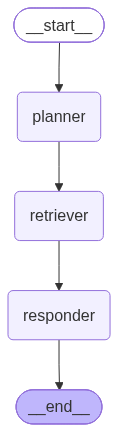

In [22]:
## Step 4 - Building Langgraph Graph

from langgraph.graph import END, START, StateGraph


builder=StateGraph(CoTStateRag)

builder.add_node("planner", plan_steps)
builder.add_node("retriever", retrieve_per_step)
builder.add_node("responder", generate_answer)

# =========
# builder.add_edge(START, "planner")
# == OR ===
builder.set_entry_point("planner")
# =========
builder.add_edge("planner", "retriever")
builder.add_edge("retriever", "responder")
builder.add_edge("responder", END)

graph = builder.compile()
graph

In [24]:
## Step 5 - Run CoT RAG Agent

if __name__ == "__main__":
    query = "How File System as Persistent Memory work?"
    state = CoTStateRag(question=query)
    final_result = graph.invoke(state)

    print("\n Reasoning Steps:", final_result["sub_steps"])
    print("\n Final Answer:", final_result["answer"])


 Reasoning Steps: ['To understand how a file system as persistent memory works, we can break the explanation into the following reasoning steps:', '1. **Integration with Non-Volatile Memory (NVM):**', 'Persistent memory combines the speed and byte-addressability of DRAM with the persistence of traditional storage like SSDs or hard drives. The file system takes advantage of non-volatile memory technologies (such as Intel Optane or NVDIMM) that retain data even when the power is turned off. This integration allows data to be directly accessed and manipulated in place rather than being shuttled through multiple layers like RAM and storage, reducing latency and improving performance.', '2. **File System Design and Architecture:**', 'A file system designed for persistent memory must efficiently manage the data and metadata operations, ensuring integrity, consistency, and reliability. It should support memory-mapped file access, enabling applications to use simple load/store instructions as